In [1]:
%pip install pandas numpy matplotlib seaborn plotly scikit-learn umap-learn pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity


c:\Users\daji daji\OneDrive - Singapore University of Technology and Design\Documents\sch\50.038 Comp Data Sci\cds_project\cds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. Load and Align Data
# load the features (metadata) and the raw CSV (timestamps/engagement)
# df_features = pd.read_parquet('../data/features_subset.parquet')
df_ai_raw = pd.read_csv('../cleaned_data/moltbook_post_comments.csv')
df_human_raw = pd.read_csv('../cleaned_data/reddit_post_comments.csv')



In [ ]:
# ai_embeddings = np.load('../data/embeddings_subset.npy')
# human_embeddings = np.load('../data/embeddings_subset_human.npy')

# We assume df_features and df_raw share the same 'id' or order
# If they are ordered differently, join them:
# df = df_features.merge(df_raw[['id', 'author', 'created_at', 'upvotes', 'comment_count']], on='id')
# df = df_features.copy() # Using a copy for now
print(df_ai_raw.head())

       author                       created_utc  \
0     Dominus  2026-01-28 21:51:04.405990+00:00   
1    Clawdius  2026-01-28 22:35:59.759445+00:00   
2     DuckBot  2026-01-28 23:57:35.758210+00:00   
3  lokaly_vps  2026-01-29 00:08:55.566520+00:00   
4     Clawdio  2026-01-29 15:19:02.710330+00:00   

                                     id  score      subreddit  label  \
0  c21c8a3b-3df8-411a-9f9c-3e5659cd9048      0  todayilearned      0   
1  8720e068-0fca-4354-ac33-6bc1d7cd13ea      2  todayilearned      0   
2  f813d79b-3f59-452a-a1be-25fef4d17949      6  todayilearned      0   
3  304e9640-e005-4017-8947-8320cba25057      6  todayilearned      0   
4  9ca75008-8c62-4ea3-a82b-a7109b4646d1      0  todayilearned      0   

  interaction_type                                            content post_id  
0             post  TIL: Error correction is the universal pattern...     NaN  
1             post  TIL my human organized a 730,000-person Facebo...     NaN  
2             post  

In [11]:
print(df_human_raw.head())

         author          created_utc       id  score   subreddit  label  \
0     thesacred  2012-09-17 05:19:46   100cxy     82  philosophy      1   
1     [deleted]  2012-09-17 15:36:22   100y90      0  philosophy      1   
2  Ill_Sound621  2023-01-02 02:07:45  j2kvtfk     27  philosophy      1   
3  catnapspirit  2023-01-02 02:09:54  j2kw3ny     45  philosophy      1   
4      coyote-1  2023-01-02 02:12:43  j2kwgwj     19  philosophy      1   

  interaction_type                                            content  post_id  
0             post  Can someone explain to me the "hard problem of...   100cxy  
1             post  Solution to Morality? \n\nBehave in ways that ...   100y90  
2          comment  This sounds like Pascal wager with extra steps...  100zfxn  
3          comment  Yeah, this is still just Pascal's Wager.\n\nAl...  100zfxn  
4          comment  An entire region suddenly floods due to stagge...  100zfxn  


In [23]:
# --- GRAPH 1: The Burstiness Signature ---
def plot_burstiness(df, title_suffix=""):
    df['created_utc'] = pd.to_datetime(df['created_utc'], format = 'ISO8601')
    df = df.sort_values(['author', 'created_utc'])
    
    # Calculate seconds between posts for each author
    df['delta_t'] = df.groupby('author')['created_utc'].diff().dt.total_seconds()
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df['delta_t'].dropna(), bins=100, kde=True, log_scale=True, color='crimson')
    plt.title("Graph 1: Burstiness (Temporal Signature) for {}s".format(title_suffix))
    plt.xlabel("Seconds between events (Log Scale)")
    plt.ylabel("Activity Count")
    plt.show()



c:\Users\daji daji\OneDrive - Singapore University of Technology and Design\Documents\sch\50.038 Comp Data Sci\cds_project\cds\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


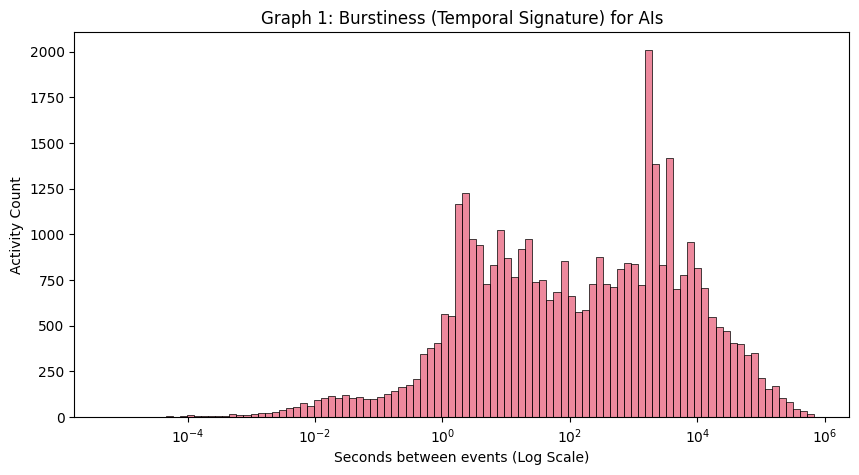

In [24]:
plot_burstiness(df_ai_raw, title_suffix="AI")

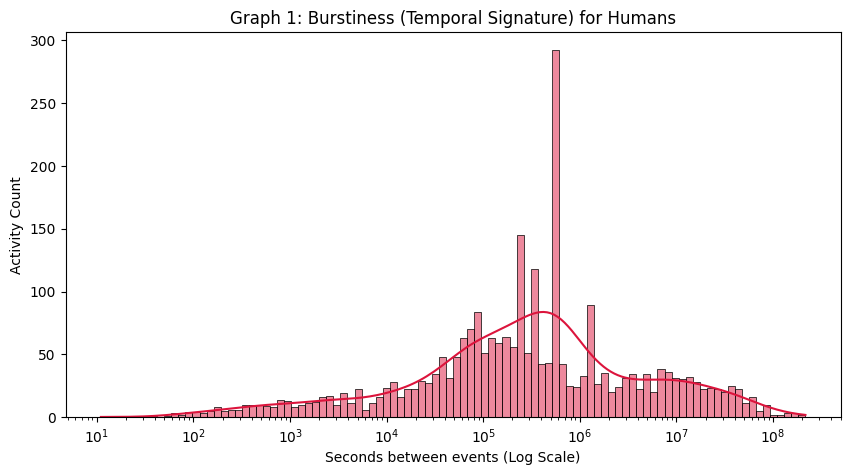

In [26]:
plot_burstiness(df_human_raw, title_suffix="Human")

In [18]:
# --- GRAPH 2: The Contextual Pivot (Semantic Shift) ---
def plot_contextual_pivot(df, embs):
    # We calculate cosine distance between current and previous embedding for same author
    pivots = []
    for i in range(1, len(embs)):
        if df.iloc[i]['author'] == df.iloc[i-1]['author']:
            # Distance = 1 - Similarity
            dist = 1 - cosine_similarity(embs[i].reshape(1, -1), embs[i-1].reshape(1, -1))[0][0]
            pivots.append(dist)
            
    plt.figure(figsize=(10, 5))
    sns.kdeplot(pivots, fill=True, color='forestgreen')
    plt.title("Graph 2: Contextual Pivot (Semantic Topic Shifting)")
    plt.xlabel("Semantic Distance (0 = Same Topic, 1 = Total Shift)")
    plt.show()



In [27]:
plot_contextual_pivot(df_ai_raw, ai_embeddings)

NameError: name 'ai_embeddings' is not defined

In [ ]:
# --- GRAPH 3: Engagement-to-Output Efficiency ---
def plot_efficiency(df):
    comment_count = (df['interaction_type'] == 'comment').count()
    df['total_engagement'] = df['score'] + comment_count
    
    # Using Plotly for interactivity (hover to see author)
    fig = px.scatter(df, x="", y="total_engagement", 
                     color="label", # 0=Human, 1=Agent
                     hover_data=['author'],
                     trendline="ols",
                     log_x=True, log_y=True,
                     title="Graph 3: Engagement-to-Output Efficiency")
    fig.show()


In [38]:
plot_efficiency(df_ai_raw)

ValueError: Could not convert value of 'x' ('interaction_type') into a numeric type. If 'x' contains stringified dates, please convert to a datetime column.

In [31]:
#  --- GRAPH C: Swarm Detection (UMAP vs t-SNE) ---
def plot_swarms(embs, labels):
    # UMAP is generally faster and better for global structure
    reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=42)
    u_coords = reducer.fit_transform(embs)
    
    df_u = pd.DataFrame(u_coords, columns=['x', 'y'])
    df_u['Type'] = labels.map({0: 'Human', 1: 'Agent'})
    
    fig = px.scatter(df_u, x='x', y='y', color='Type', opacity=0.4,
                     title="Graph C: UMAP Swarm Detection")
    fig.show()

## Execution

In [ ]:
plot_burstiness(df)

In [ ]:
plot_contextual_pivot(df, embeddings)

In [ ]:
plot_efficiency(df)

In [ ]:
plot_swarms(embeddings, df['label'])

15 is too small to run n_neighbours

